# 03 · Análise estatística

**Teste prático de Analytics Engineer (estágio) · Klubi**

Tarefa 3 do desafio: calcular correlações entre hábitos e notas, e identificar quais variáveis têm maior influência positiva e negativa.

### Índice

1. Setup
2. Base preparada
3. Matriz de correlação
4. Pearson contra Spearman
5. Ranking de influência
6. O efeito teto na prática
7. O que sobra depois de descontar o estudo
8. Quanto vale cada hábito, em pontos
9. Síntese

A seção 7 é a que muda a leitura de tudo. As correlações simples das seções 3 a 5 são corretas e, ainda assim, subestimam sistematicamente todo hábito que não seja horas de estudo.

## 1. Setup

In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

CSV = Path("../data/raw/habitos_e_desempenho_estudantil.csv")
if not CSV.exists():
    CSV = Path("data/raw/habitos_e_desempenho_estudantil.csv")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

print(f"pandas {pd.__version__}  ·  numpy {np.__version__}")

pandas 3.0.6  ·  numpy 2.5.3


In [2]:
# Mesma paleta dos notebooks 01 e 02.
COR = {
    "serie_1":    "#2a78d6",  # azul, influência positiva
    "serie_2":    "#eb6834",  # laranja, influência negativa
    "critico":    "#d03b3b",
    "superficie": "#fcfcfb",
    "tinta":      "#0b0b0b",
    "tinta_2":    "#52514e",
    "suave":      "#898781",
    "grade":      "#e1e0d9",
    "eixo":       "#c3c2b7",
    "neutro":     "#f0efec",  # meio da escala divergente: "nenhuma relação"
}

plt.rcParams.update({
    "figure.facecolor":   COR["superficie"],
    "axes.facecolor":     COR["superficie"],
    "savefig.facecolor":  COR["superficie"],
    "figure.dpi":         110,
    "font.family":        "sans-serif",
    "font.size":          9.5,
    "text.color":         COR["tinta"],
    "axes.titlesize":     10.5,
    "axes.titleweight":   "bold",
    "axes.titlecolor":    COR["tinta"],
    "axes.titlelocation": "left",
    "axes.titlepad":      9,
    "axes.labelsize":     9,
    "axes.labelcolor":    COR["tinta_2"],
    "axes.edgecolor":     COR["eixo"],
    "axes.linewidth":     0.8,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "axes.axisbelow":     True,
    "grid.color":         COR["grade"],
    "grid.linewidth":     0.8,
    "grid.linestyle":     "-",
    "xtick.color":        COR["suave"],
    "ytick.color":        COR["suave"],
    "xtick.labelsize":    8.5,
    "ytick.labelsize":    8.5,
    "xtick.bottom":       False,
    "ytick.left":         False,
    "legend.frameon":     False,
    "legend.fontsize":    9,
})


def so_grade(ax, eixo="y"):
    "Deixa grade em um eixo só. O dado é a única coisa que pode ser forte."
    ax.grid(axis=eixo, visible=True)
    ax.grid(axis="x" if eixo == "y" else "y", visible=False)
    return ax


# Escala divergente para a matriz de correlação: laranja para relação negativa,
# cinza neutro no zero (precisa ler como "nada"), azul para positiva. Nunca
# arco-íris, e nunca uma cor viva no meio.
DIVERGENTE = LinearSegmentedColormap.from_list(
    "corr", ["#b4441a", COR["serie_2"], "#f5c4ad", COR["neutro"],
             "#9ec5f4", COR["serie_1"], "#184f95"],
)

## 2. Base preparada

A célula abaixo é a função `preparar_dados()` fechada no [notebook 02](02_engenharia_de_dados.ipynb), copiada sem alteração. Foi a decisão tomada lá: nada de base tratada em disco, e um único bloco canônico que os notebooks seguintes colam.

In [3]:
INTEIRAS = ["age", "exercise_frequency", "mental_health_rating"]
DECIMAIS = [
    "study_hours_per_day", "social_media_hours", "netflix_hours",
    "attendance_percentage", "sleep_hours", "exam_score",
]
ORDINAIS = {
    "diet_quality":             ["Poor", "Fair", "Good"],
    "internet_quality":         ["Poor", "Average", "Good"],
    "parental_education_level": ["None", "High School", "Bachelor", "Master"],
}
FAIXAS = {
    "faixa_estudo": ("study_hours_per_day", [0, 2, 3, 4, 5, np.inf],
                     ["menos de 2h", "2h a 3h", "3h a 4h", "4h a 5h", "5h ou mais"]),
    "faixa_redes":  ("social_media_hours", [0, 1, 2, 3, 4, np.inf],
                     ["menos de 1h", "1h a 2h", "2h a 3h", "3h a 4h", "4h ou mais"]),
    "faixa_sono":   ("sleep_hours", [0, 6, 7, 8, np.inf],
                     ["menos de 6h", "6h a 7h", "7h a 8h", "8h ou mais"]),
}


def preparar_dados(csv=CSV):
    "Lê o CSV cru e devolve a base tratada. Idêntica à do notebook 02."
    base = pd.read_csv(csv, dtype=str, na_filter=False)
    base[INTEIRAS] = base[INTEIRAS].astype(int)
    base[DECIMAIS] = base[DECIMAIS].astype(float)

    for coluna, ordem in ORDINAIS.items():
        base[coluna] = pd.Categorical(base[coluna], categories=ordem, ordered=True)
        base[f"{coluna}_cod"] = base[coluna].cat.codes

    base["tempo_tela_total"] = base["social_media_hours"] + base["netflix_hours"]

    for nova, (origem, cortes, rotulos) in FAIXAS.items():
        base[nova] = pd.cut(base[origem], bins=cortes, labels=rotulos,
                            right=False, ordered=True)
    return base


df = preparar_dados()
print(f"{df.shape[0]} linhas × {df.shape[1]} colunas  ·  NaN: {int(df.isna().sum().sum())}")

1000 linhas × 23 colunas  ·  NaN: 0


In [4]:
# Os dois binários viram 0/1 para entrar na matriz. Correlação de Pearson entre
# uma variável contínua e uma dummy é a correlação ponto-bisserial, que é
# interpretável do mesmo jeito.
for coluna in ["part_time_job", "extracurricular_participation"]:
    df[f"{coluna}_bin"] = (df[coluna] == "Yes").astype(int)

# Ordem fixa usada em todas as tabelas e gráficos deste notebook.
PREDITORES = [
    "study_hours_per_day", "mental_health_rating", "tempo_tela_total",
    "netflix_hours", "social_media_hours", "exercise_frequency", "sleep_hours",
    "attendance_percentage", "internet_quality_cod", "part_time_job_bin",
    "parental_education_level_cod", "diet_quality_cod", "age",
    "extracurricular_participation_bin",
]
ALVO = "exam_score"

alvo = df[ALVO]
print(f"{len(PREDITORES)} preditores contra {ALVO}")

14 preditores contra exam_score


## 3. Matriz de correlação

`gender` fica de fora da matriz por ter três categorias sem ordem, o que não cabe numa correlação. Ela volta na tarefa 6, comparada por médias de grupo.

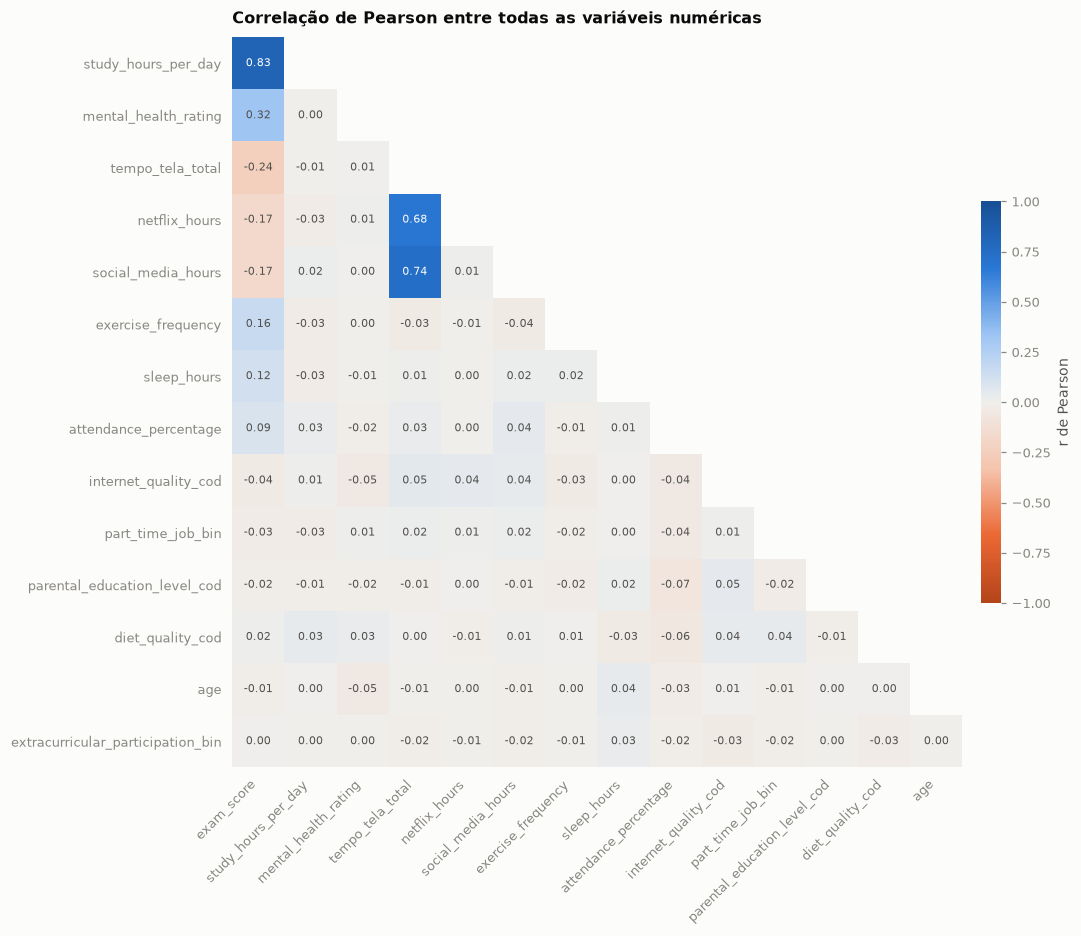

In [5]:
colunas = [ALVO] + PREDITORES
matriz = df[colunas].corr()

fig, ax = plt.subplots(figsize=(10.5, 8.6))

# Só o triângulo inferior estrito. A matriz é simétrica, então a metade de cima
# repetiria tudo, e a diagonal é sempre 1,00: tautologia que só rouba atenção.
# Fora a primeira linha e a última coluna, que no triângulo estrito ficariam
# sem nenhuma célula.
recorte = matriz.iloc[1:, :-1]
mascara = np.triu(np.ones(recorte.shape, dtype=bool), k=1)
visivel = recorte.mask(mascara)

im = ax.imshow(visivel, cmap=DIVERGENTE, vmin=-1, vmax=1)

for i in range(recorte.shape[0]):
    for j in range(i + 1):
        v = recorte.iloc[i, j]
        texto = f"{v:.2f}"
        if texto == "-0.00":      # zero negativo é ruído de arredondamento
            texto = "0.00"
        # Texto branco sobre célula escura, tinta sobre célula clara.
        cor_txt = COR["superficie"] if abs(v) > 0.55 else COR["tinta_2"]
        ax.text(j, i, texto, ha="center", va="center",
                fontsize=7.5, color=cor_txt)

ax.set_xticks(range(recorte.shape[1]), recorte.columns, rotation=45, ha="right")
ax.set_yticks(range(recorte.shape[0]), recorte.index)
ax.set_title("Correlação de Pearson entre todas as variáveis numéricas")
ax.grid(visible=False)
for lado in ax.spines.values():
    lado.set_visible(False)

barra = fig.colorbar(im, ax=ax, shrink=0.55, pad=0.02)
barra.set_label("r de Pearson", color=COR["tinta_2"], fontsize=9)
barra.outline.set_visible(False)

plt.tight_layout()
plt.show()

Duas leituras, e a segunda é mais surpreendente que a primeira.

**A primeira coluna** é a que a tarefa pede: `study_hours_per_day` domina com 0,83, `mental_health_rating` vem em segundo com 0,32, e depois o bloco de tempo de tela em negativo. Da metade da tabela para baixo tudo encosta em zero.

**O resto da matriz está praticamente vazio.** Fora da primeira coluna e dos pares que se contêm por construção (`tempo_tela_total` com suas duas parcelas), nenhuma correlação entre dois preditores passa de 0,07.

In [6]:
# Quão independentes são os preditores entre si? Descarto os pares em que uma
# variável contém a outra, porque ali a correlação é artefato de construção.
CONTIDOS = {("tempo_tela_total", "social_media_hours"),
            ("tempo_tela_total", "netflix_hours")}

pares = []
for i, a in enumerate(PREDITORES):
    for b in PREDITORES[i + 1:]:
        if (a, b) in CONTIDOS or (b, a) in CONTIDOS:
            continue
        pares.append({"a": a, "b": b, "r": matriz.loc[a, b]})

pares = pd.DataFrame(pares)
print(f"pares de preditores avaliados: {len(pares)}")
print(f"maior |r| entre dois preditores: {pares['r'].abs().max():.3f}")
print()
print("os cinco pares mais correlacionados:")
print(pares.reindex(pares["r"].abs().sort_values(ascending=False).index).head(5).to_string(index=False))

pares de preditores avaliados: 89
maior |r| entre dois preditores: 0.072

os cinco pares mais correlacionados:
                    a                            b      r
attendance_percentage parental_education_level_cod -0.072
attendance_percentage             diet_quality_cod -0.059
     tempo_tela_total         internet_quality_cod  0.054
 mental_health_rating         internet_quality_cod -0.048
 internet_quality_cod parental_education_level_cod  0.046


**Dos 89 pares de preditores, o mais correlacionado fica em 0,072**, o que significa meio por cento de variação compartilhada. Os hábitos desta base são mutuamente independentes: quem estuda mais não dorme menos, quem usa mais rede social não se exercita menos, e assim por diante.

Isso tem duas consequências opostas.

A boa: **não há multicolinearidade**. Cada variável carrega informação própria, os coeficientes de uma regressão múltipla serão estáveis, e não existe risco de dois preditores brigarem pelo mesmo crédito.

A ruim: **é irreal**. Em estudantes de verdade os hábitos vêm em pacote, e quem dorme mal costuma também estudar menos e usar mais tela à noite. Independência perfeita entre nove hábitos é assinatura de dado gerado por sorteio de cada coluna em separado, o que confirma o que o notebook 01 já suspeitava. As relações encontradas aqui são reais dentro da base, mas a base não reproduz a estrutura de correlação do mundo.

## 4. Pearson contra Spearman

O notebook 02 codificou três ordinais como inteiro (`Poor` vira 0, `Fair` vira 1, `Good` vira 2) e deixou uma ressalva registrada: **ordem não é distância**. Pearson assume que o salto de `Poor` para `Fair` vale o mesmo que o de `Fair` para `Good`, e nada garante isso.

Spearman não faz essa suposição, porque trabalha só com a posição de cada valor na fila. Se as duas discordarem muito, a codificação inteira está distorcendo. Se concordarem, a aproximação é segura e a relação é monótona.

In [7]:
# Spearman é, por definição, Pearson aplicado aos postos. Calcular assim evita
# uma dependência a mais e deixa explícito o que o método faz.
postos = df[colunas].rank()

comparacao = pd.DataFrame({
    "pearson": matriz[ALVO].drop(ALVO),
    "spearman": postos.corr()[ALVO].drop(ALVO),
})
comparacao["diferenca"] = comparacao["spearman"] - comparacao["pearson"]
comparacao = comparacao.reindex(comparacao["pearson"].abs().sort_values(ascending=False).index)
comparacao

,pearson,spearman,diferenca
study_hours_per_day,0.825,0.812,-0.013
mental_health_rating,0.322,0.323,0.002
tempo_tela_total,-0.238,-0.228,0.010
netflix_hours,-0.172,-0.165,0.007
social_media_hours,-0.167,-0.166,0.000
exercise_frequency,0.160,0.150,-0.010
sleep_hours,0.122,0.123,0.002
attendance_percentage,0.090,0.094,0.004
internet_quality_cod,-0.036,-0.046,-0.009
part_time_job_bin,-0.027,-0.030,-0.004


**A maior discordância é de 0,013**, em `study_hours_per_day`. Todas as outras ficam em 0,01 ou menos.

Isso libera duas coisas ao mesmo tempo. A codificação inteira das ordinais está validada: tratá-las como número não distorceu nada, e o notebook 02 pode manter as colunas `_cod` sem ressalva. E as relações são **monótonas e aproximadamente lineares**, já que Pearson (que mede relação linear) e Spearman (que mede só monotonicidade) chegam ao mesmo lugar. Se houvesse curva, saturação ou ponto de virada em alguma variável, as duas teriam se afastado.

## 5. Ranking de influência

Com n de 1.000, quase tudo passa em teste de significância: um r de 0,07 já sai com p abaixo de 0,05 e não quer dizer nada de útil. Por isso o ranking abaixo traz **intervalo de confiança** em vez de p-valor. O intervalo responde a pergunta certa, que é "de que tamanho é o efeito, e com quanta incerteza", e não "o efeito é diferente de zero".

In [8]:
def ic_fisher(r, n, confianca=0.95):
    "Intervalo de confiança de uma correlação pela transformação z de Fisher."
    # r não é normalmente distribuído, mas arctanh(r) é aproximadamente, com
    # erro-padrão 1/sqrt(n-3). Calcula o intervalo lá e traz de volta com tanh.
    z = np.arctanh(r)
    margem = 1.96 / math.sqrt(n - 3)
    return np.tanh(z - margem), np.tanh(z + margem)


n = len(df)
ranking = pd.DataFrame({"r": matriz[ALVO].drop(ALVO)})
ranking[["ic_baixo", "ic_alto"]] = pd.DataFrame(
    [ic_fisher(r, n) for r in ranking["r"]], index=ranking.index
)
# Se o intervalo de 95% contém o zero, o sinal da correlação não está
# estabelecido, e pintar de azul ou laranja afirmaria uma direção que o dado
# não sustenta.
cruza_zero = (ranking["ic_baixo"] < 0) & (ranking["ic_alto"] > 0)
ranking["direcao"] = np.where(cruza_zero, "indefinida",
                              np.where(ranking["r"] > 0, "positiva", "negativa"))
# r ao quadrado: fração da variação da nota que a variável acompanha sozinha.
ranking["r2_pct"] = (ranking["r"] ** 2 * 100).round(1)
ranking = ranking.reindex(ranking["r"].abs().sort_values(ascending=False).index)
ranking

,r,ic_baixo,ic_alto,direcao,r2_pct
study_hours_per_day,0.825,0.805,0.844,positiva,68.100
mental_health_rating,0.322,0.265,0.376,positiva,10.300
tempo_tela_total,-0.238,-0.295,-0.178,negativa,5.600
netflix_hours,-0.172,-0.231,-0.111,negativa,3.000
social_media_hours,-0.167,-0.226,-0.106,negativa,2.800
exercise_frequency,0.160,0.099,0.220,positiva,2.600
sleep_hours,0.122,0.060,0.182,positiva,1.500
attendance_percentage,0.090,0.028,0.151,positiva,0.800
internet_quality_cod,-0.036,-0.098,0.026,indefinida,0.100
part_time_job_bin,-0.027,-0.088,0.035,indefinida,0.100


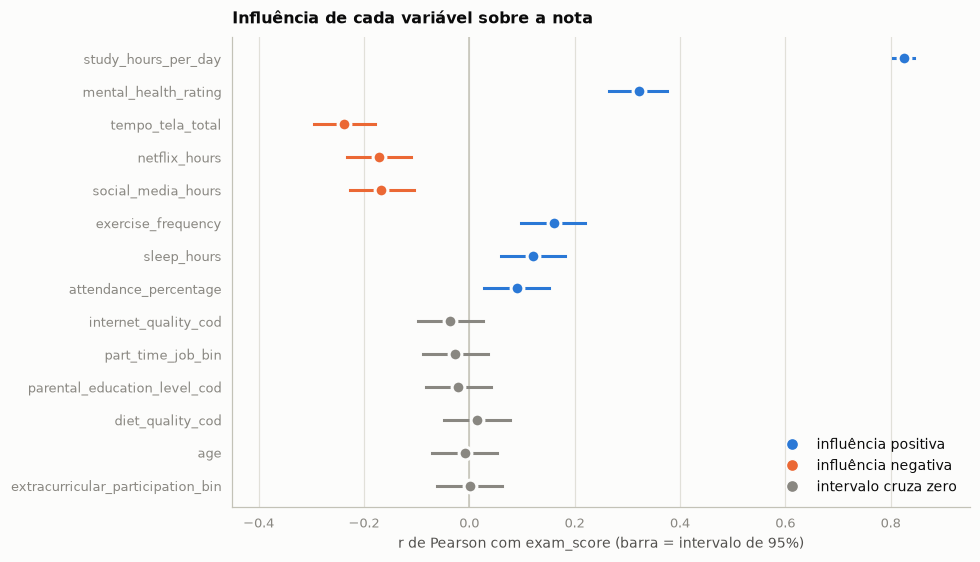

In [9]:
fig, ax = plt.subplots(figsize=(9, 5.2))

r = ranking.iloc[::-1]   # menor no topo do array vira menor embaixo no gráfico
y = np.arange(len(r))
PINTURA = {"positiva": COR["serie_1"], "negativa": COR["serie_2"],
           "indefinida": COR["suave"]}
cores = [PINTURA[d] for d in r["direcao"]]

ax.axvline(0, color=COR["eixo"], linewidth=1, zorder=1)
for i, (cor, linha) in enumerate(zip(cores, r.itertuples())):
    ax.plot([linha.ic_baixo, linha.ic_alto], [i, i], color=cor, linewidth=2, zorder=2)
    ax.scatter(linha.r, i, s=70, color=cor,
               edgecolor=COR["superficie"], linewidth=2, zorder=3)

ax.set_yticks(y, r.index)
ax.set_xlabel("r de Pearson com exam_score (barra = intervalo de 95%)")
ax.set_title("Influência de cada variável sobre a nota")
ax.set_xlim(-0.45, 0.95)

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([], [], marker="o", linestyle="", markersize=8, markerfacecolor=COR["serie_1"],
           markeredgecolor=COR["superficie"], label="influência positiva"),
    Line2D([], [], marker="o", linestyle="", markersize=8, markerfacecolor=COR["serie_2"],
           markeredgecolor=COR["superficie"], label="influência negativa"),
    Line2D([], [], marker="o", linestyle="", markersize=8, markerfacecolor=COR["suave"],
           markeredgecolor=COR["superficie"], label="intervalo cruza zero"),
], loc="lower right")
so_grade(ax, eixo="x")
plt.tight_layout()
plt.show()

**Maior influência positiva: `study_hours_per_day`**, com r de 0,825 e intervalo de 95% entre 0,805 e 0,844. Sozinha ela acompanha 68% da variação da nota. É a única variável da base em outra ordem de grandeza.

**Maior influência negativa: `tempo_tela_total`**, com -0,238, seguida das suas duas parcelas separadas.

As **seis variáveis em cinza** têm intervalo de confiança contendo o zero, o que significa que nem o sinal da relação está estabelecido: `internet_quality`, `part_time_job`, `parental_education_level`, `diet_quality`, `age` e `extracurricular_participation` são indistinguíveis de nenhuma relação. A de escolaridade dos pais já tinha sido diagnosticada como inerte no notebook 01.

Vale registrar o que surpreende: **`attendance_percentage` quase não importa** (0,090), e **`diet_quality` não importa nada** (0,015). Frequência às aulas e alimentação são os dois hábitos que mais aparecem em conselho escolar, e nesta base nenhum dos dois segura a nota.

## 6. O efeito teto na prática

O notebook 01 encontrou 48 alunos com nota exatamente 100,0 e alertou que a censura no topo **atenua** as correlações: quem mereceria 110 aparece como 100, o que achata a inclinação da relação.

O reflexo é remover esses 48 e recalcular. Vale testar se funciona.

In [10]:
sem_teto = df[df[ALVO] < 100]

teto = pd.DataFrame({
    "com_os_48": matriz[ALVO].drop(ALVO),
    "sem_os_48": sem_teto[colunas].corr()[ALVO].drop(ALVO),
})
teto["mudanca"] = teto["sem_os_48"] - teto["com_os_48"]
teto = teto.reindex(teto["com_os_48"].abs().sort_values(ascending=False).index)
teto.head(8)

,com_os_48,sem_os_48,mudanca
study_hours_per_day,0.825,0.799,-0.027
mental_health_rating,0.322,0.301,-0.020
tempo_tela_total,-0.238,-0.227,0.011
netflix_hours,-0.172,-0.156,0.016
social_media_hours,-0.167,-0.165,0.002
exercise_frequency,0.160,0.121,-0.039
sleep_hours,0.122,0.105,-0.017
attendance_percentage,0.090,0.072,-0.018


**Piorou.** Tirando os 48, `study_hours_per_day` cai de 0,825 para 0,799, saúde mental cai de 0,322 para 0,301 e exercício de 0,160 para 0,121. O oposto do esperado.

A razão é que remover os 48 resolve um problema criando outro maior. Descartar todo mundo que tirou 100 é **selecionar pela variável resposta**, e isso encurta a faixa de variação da nota. Correlação é sensível à amplitude: em qualquer amostra em que o alvo varia menos, ela cai, mesmo que a relação subjacente seja idêntica. O encurtamento da faixa custa mais do que a censura corrigida.

Então o alerta do notebook 01 continua de pé, e a conclusão aqui é sobre o que fazer com ele: **os números deste notebook devem ser lidos como piso, não como valor exato.** A relação verdadeira entre estudo e nota é um pouco mais forte que 0,825. Quanto mais forte, esta base não permite dizer, e nenhum descarte de linha vai responder. O caminho correto seria um modelo censurado (Tobit), que é mais maquinário do que esta análise exige.

## 7. O que sobra depois de descontar o estudo

Aqui está o problema das seções anteriores. `study_hours_per_day` acompanha 68% da variação da nota, e isso deforma a leitura de todo o resto: comparar saúde mental (0,32) com horas de estudo (0,83) faz saúde mental parecer secundária.

Mas a pergunta prática de um coordenador não é essa. É: **entre dois alunos que estudam o mesmo tanto, o que ainda separa as notas deles?**

Quem responde isso é a correlação parcial. Removo de cada variável e da nota a parte explicada por horas de estudo, e correlaciono o que sobra.

In [11]:
def residuo(serie, controle):
    "Devolve a parte de `serie` que não é explicada linearmente por `controle`."
    # Ajusta uma reta serie ~ controle e guarda o que a reta não acertou.
    inclinacao, intercepto = np.polyfit(controle, serie, 1)
    return serie - (inclinacao * controle + intercepto)


controle = df["study_hours_per_day"]
alvo_residual = residuo(alvo, controle)

outros = [c for c in PREDITORES if c != "study_hours_per_day"]
parcial = pd.DataFrame({
    "r_simples": [df[c].corr(alvo) for c in outros],
    "r_parcial": [residuo(df[c], controle).corr(alvo_residual) for c in outros],
}, index=outros)
parcial["fator"] = parcial["r_parcial"].abs() / parcial["r_simples"].abs()
parcial = parcial.reindex(parcial["r_parcial"].abs().sort_values(ascending=False).index)
parcial.head(8)

,r_simples,r_parcial,fator
mental_health_rating,0.322,0.575,1.789
tempo_tela_total,-0.238,-0.412,1.734
exercise_frequency,0.160,0.326,2.034
social_media_hours,-0.167,-0.325,1.950
netflix_hours,-0.172,-0.259,1.507
sleep_hours,0.122,0.256,2.106
attendance_percentage,0.090,0.121,1.344
internet_quality_cod,-0.036,-0.085,2.354


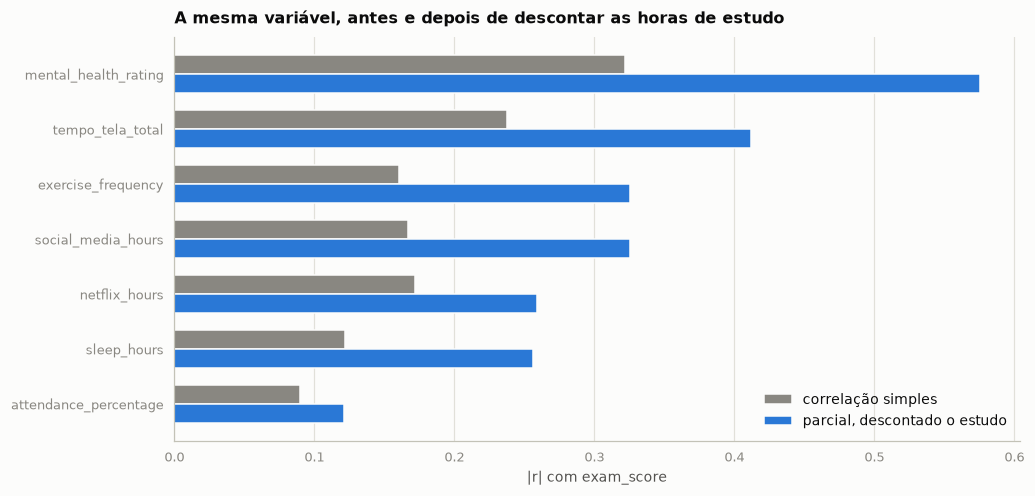

In [12]:
fig, ax = plt.subplots(figsize=(9.5, 4.6))

p = parcial.head(7).iloc[::-1]
y = np.arange(len(p))
altura = 0.34

ax.barh(y + altura / 2, p["r_simples"].abs(), height=altura, color=COR["suave"],
        edgecolor=COR["superficie"], linewidth=1, label="correlação simples")
ax.barh(y - altura / 2, p["r_parcial"].abs(), height=altura, color=COR["serie_1"],
        edgecolor=COR["superficie"], linewidth=1, label="parcial, descontado o estudo")

ax.set_yticks(y, p.index)
ax.set_xlabel("|r| com exam_score")
ax.set_title("A mesma variável, antes e depois de descontar as horas de estudo")
ax.legend(loc="lower right")
so_grade(ax, eixo="x")
plt.tight_layout()
plt.show()

**Todo hábito quase dobra de tamanho.**

| Variável | simples | parcial |
|---|---|---|
| `mental_health_rating` | 0,322 | **0,575** |
| `tempo_tela_total` | -0,238 | **-0,412** |
| `social_media_hours` | -0,167 | **-0,325** |
| `exercise_frequency` | 0,160 | **0,326** |
| `netflix_hours` | -0,172 | **-0,259** |
| `sleep_hours` | 0,122 | **0,256** |

Não é truque de estatística, e a explicação é direta: horas de estudo consomem 68% da variação da nota, então sobram 32% para todo o resto disputar. Medir os outros hábitos contra a variação total faz todos parecerem fracos. Medidos contra o que ainda está em aberto, saúde mental explica mais de um terço.

A tradução prática é a que interessa para as recomendações da tarefa 6: **horas de estudo é o fator dominante, mas é também o mais difícil de mudar por decreto.** Entre alunos que já estudam a mesma quantidade, saúde mental e tempo de tela são os que mais separam o resultado, e são justamente onde uma intervenção tem alcance.

Uma ressalva honesta: correlação parcial mostra associação independente, não causa. O notebook 01 já registrou que a base é sintética, e a seção 3 mostrou que os hábitos aqui são independentes por construção. Nada disso prova que reduzir tela eleva nota.

## 8. Quanto vale cada hábito, em pontos

Correlação é adimensional, e ninguém decide nada com "r igual a 0,32". Uma regressão múltipla traduz a mesma informação para a unidade que importa: pontos de nota.

Cabe aqui e não na tarefa 4 porque o objetivo é **medir influência**, que é o que a tarefa 3 pede. Usar o modelo para prever aluno novo é assunto do notebook 04.

In [13]:
MODELO = ["study_hours_per_day", "mental_health_rating", "tempo_tela_total",
          "exercise_frequency", "sleep_hours", "attendance_percentage"]

# Mínimos quadrados via numpy: a coluna de 1s é o intercepto.
X = np.column_stack([np.ones(len(df))] + [df[c].to_numpy() for c in MODELO])
y = alvo.to_numpy()
coeficientes, *_ = np.linalg.lstsq(X, y, rcond=None)

previsto = X @ coeficientes
r2 = 1 - ((y - previsto) ** 2).sum() / ((y - y.mean()) ** 2).sum()

efeitos = pd.DataFrame({
    "por_unidade": coeficientes[1:],
    # Coeficiente vezes o desvio-padrão da variável: põe hábitos medidos em
    # unidades diferentes (horas, escala de 1 a 10, percentual) na mesma régua.
    "por_1_desvio": [b * df[c].std() for c, b in zip(MODELO, coeficientes[1:])],
}, index=MODELO)
efeitos = efeitos.reindex(efeitos["por_1_desvio"].abs().sort_values(ascending=False).index)

print(f"R² do modelo com {len(MODELO)} variáveis : {r2:.3f}")
print(f"R² de study_hours_per_day sozinha    : {alvo.corr(df['study_hours_per_day']) ** 2:.3f}")
print()
efeitos

R² do modelo com 6 variáveis : 0.901
R² de study_hours_per_day sozinha    : 0.681



,por_unidade,por_1_desvio
study_hours_per_day,9.568,14.054
mental_health_rating,1.949,5.551
tempo_tela_total,-2.463,-3.940
exercise_frequency,1.454,2.946
sleep_hours,2.002,2.455
attendance_percentage,0.144,1.353


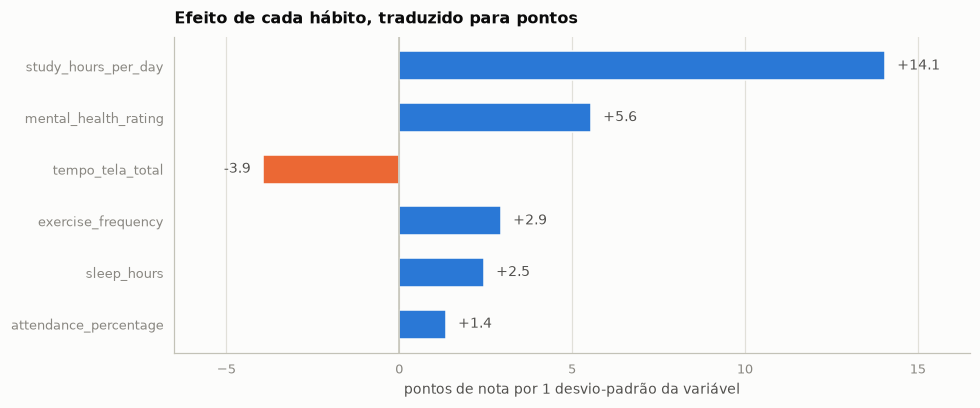

In [14]:
fig, ax = plt.subplots(figsize=(9, 3.8))

e = efeitos.iloc[::-1]
cores = [COR["serie_1"] if v > 0 else COR["serie_2"] for v in e["por_1_desvio"]]

ax.barh(np.arange(len(e)), e["por_1_desvio"], height=0.56, color=cores,
        edgecolor=COR["superficie"], linewidth=1)
ax.axvline(0, color=COR["eixo"], linewidth=1)

# Rótulo direto na ponta de cada barra, do lado de fora, para nunca ser cortado.
for i, v in enumerate(e["por_1_desvio"]):
    desloc = 0.35 if v > 0 else -0.35
    ax.text(v + desloc, i, f"{v:+.1f}", va="center",
            ha="left" if v > 0 else "right", fontsize=9, color=COR["tinta_2"])

ax.set_yticks(np.arange(len(e)), e.index)
ax.set_xlabel("pontos de nota por 1 desvio-padrão da variável")
ax.set_title("Efeito de cada hábito, traduzido para pontos")
ax.set_xlim(-6.5, 16.5)
so_grade(ax, eixo="x")
plt.tight_layout()
plt.show()

Os seis hábitos juntos explicam **90,1%** da variação da nota, contra 68,1% de horas de estudo sozinha. Os 22 pontos percentuais de diferença são exatamente o que a seção 7 mostrou: os outros hábitos importam, só ficavam escondidos atrás do dominante.

Em unidade que dá para usar numa conversa:

1. **Cada hora a mais de estudo por dia vale +9,6 pontos** na nota.
2. **Cada ponto na escala de saúde mental vale +2,0 pontos.**
3. **Cada hora de tela por lazer custa -2,5 pontos.**
4. **Cada hora a mais de sono vale +2,0 pontos**, e cada dia de exercício na semana vale +1,5.
5. **Frequência às aulas vale +0,14 ponto por ponto percentual**, ou seja, ir de 80% para 90% de presença rende 1,4 ponto. É o menor efeito dos seis.

A coluna `por_1_desvio` é a comparação justa, porque põe horas e escalas de 1 a 10 na mesma régua: um desvio-padrão a mais de estudo vale 14,1 pontos, contra 5,6 de saúde mental e -3,9 de tempo de tela.

## 9. Síntese

### Quais hábitos mais afetam a nota

| Posição | Variável | r simples | r parcial | Pontos por 1 dp |
|---|---|---|---|---|
| 1 | `study_hours_per_day` | +0,825 | referência | **+14,1** |
| 2 | `mental_health_rating` | +0,322 | +0,575 | +5,6 |
| 3 | `tempo_tela_total` | -0,238 | -0,412 | -3,9 |
| 4 | `exercise_frequency` | +0,160 | +0,326 | +2,9 |
| 5 | `sleep_hours` | +0,122 | +0,256 | +2,5 |
| 6 | `attendance_percentage` | +0,090 | +0,121 | +1,4 |

Sem efeito detectável: `internet_quality`, `part_time_job`, `parental_education_level`, `diet_quality`, `age` e `extracurricular_participation`.

### Os quatro achados que mudam a leitura

1. **A correlação simples subestima todo hábito que não seja estudo.** Descontadas as horas de estudo, saúde mental salta de 0,32 para 0,575 e tempo de tela de -0,24 para -0,41. Como horas de estudo ocupa 68% da variação, medir os outros contra o total os faz parecer irrelevantes.
2. **Pearson e Spearman concordam em tudo** (maior discordância de 0,013). A codificação inteira das ordinais está validada, e as relações são monótonas e aproximadamente lineares.
3. **Não dá para consertar o efeito teto removendo os 48 alunos com nota 100.** Isso é selecionar pela variável resposta, e encurtar a faixa da nota derruba as correlações mais do que a censura as atenua. Os números aqui são piso, não valor exato.
4. **Os preditores são independentes entre si** (maior |r| de 0,072 entre 89 pares). Excelente para a estabilidade dos coeficientes, e irreal: em estudantes de verdade os hábitos vêm em pacote. Mais uma confirmação de base sintética.

### Próximo passo

**Notebook 04, aplicação prática**: transformar esses coeficientes em algo que apoie decisão, seja previsão de nota para aluno novo, simulação de cenário ou segmentação de turma.